In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Generate synthetic placement data (1000 samples)
np.random.seed(42)

n_samples = 1000

# CGPA: realistic range 5.0 to 9.5
cgpa = np.round(np.random.uniform(5.0, 9.5, n_samples), 2)

# Resume score: 0 to 100, correlated with CGPA + some noise
resume_score = np.clip(
    (cgpa - 5.0) / 4.5 * 60 + np.random.normal(20, 10, n_samples),
    0, 100
).round(2)

# Placed: logistic-like decision boundary
# Higher CGPA + higher resume_score → more likely to be placed
logit = -8.0 + 0.6 * cgpa + 0.05 * resume_score + np.random.normal(0, 0.5, n_samples)
prob = 1 / (1 + np.exp(-logit))
placed = (prob > 0.5).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'cgpa': cgpa,
    'resume_score': resume_score,
    'placed': placed
})

print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nPlacement ratio:\n{df['placed'].value_counts(normalize=True)}")




   cgpa  resume_score  placed
0  6.69         44.31       0
1  9.28         63.71       1
2  8.29         67.67       0
3  7.69         61.97       1
4  5.70         34.93       0
5  5.70         40.14       0
6  5.26         31.81       0
7  8.90         76.59       1
8  7.71         55.43       0
9  8.19         45.92       0

Shape: (1000, 3)

Placement ratio:
placed
0    0.701
1    0.299
Name: proportion, dtype: float64


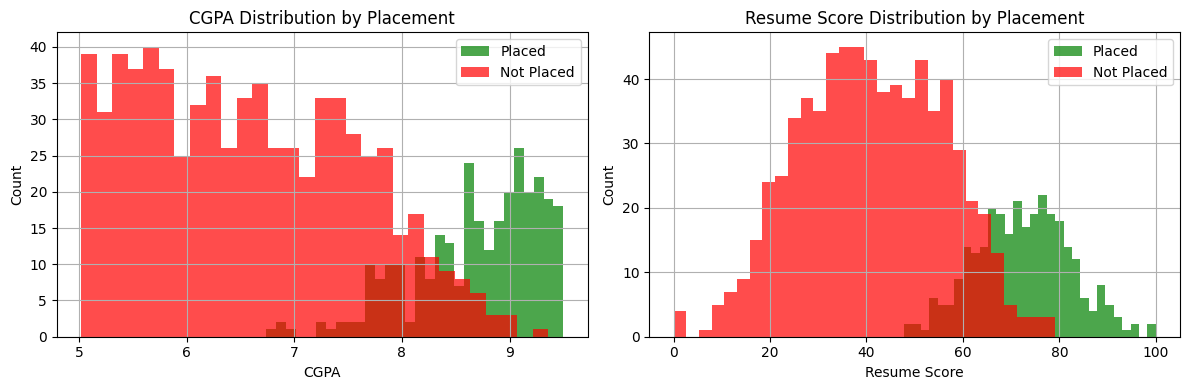

In [3]:
# Optional: visualize the data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CGPA distribution by placement status
df[df['placed'] == 1]['cgpa'].hist(ax=axes[0], bins=30, alpha=0.7, label='Placed', color='green')
df[df['placed'] == 0]['cgpa'].hist(ax=axes[0], bins=30, alpha=0.7, label='Not Placed', color='red')
axes[0].set_xlabel('CGPA')
axes[0].set_ylabel('Count')
axes[0].set_title('CGPA Distribution by Placement')
axes[0].legend()

# Resume score distribution by placement status
df[df['placed'] == 1]['resume_score'].hist(ax=axes[1], bins=30, alpha=0.7, label='Placed', color='green')
df[df['placed'] == 0]['resume_score'].hist(ax=axes[1], bins=30, alpha=0.7, label='Not Placed', color='red')
axes[1].set_xlabel('Resume Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Resume Score Distribution by Placement')
axes[1].legend()

plt.tight_layout()
plt.show()


<Axes: xlabel='cgpa', ylabel='resume_score'>

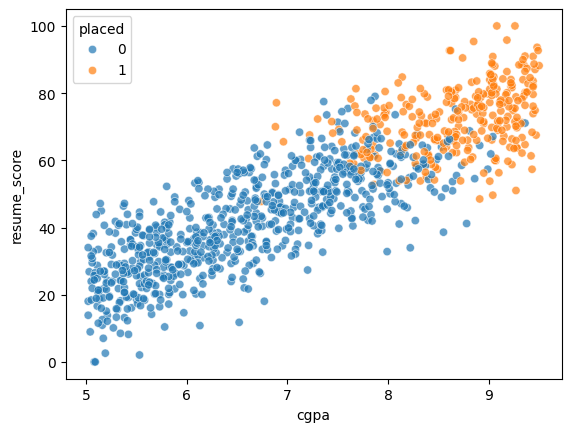

In [4]:
import seaborn as sns

sns.scatterplot(data=df, x='cgpa', y='resume_score', hue='placed', alpha=0.7)

In [5]:
x = df.iloc[:, :2]
y = df.iloc[:, 2]

In [6]:
from sklearn.linear_model import Perceptron

p = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
p.fit(x, y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


In [7]:
p.coef_

array([[-1190.4 ,   158.36]])

In [8]:
p.intercept_

array([-745.])

c:\Users\pawan\anaconda34\envs\mlproject\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Perceptron Decision Boundary')

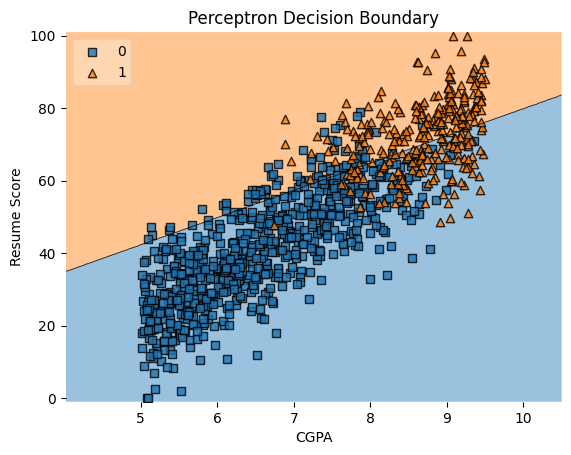

In [11]:
from mlxtend.plotting import plot_decision_regions  

plot_decision_regions(x.values, y.values, clf=p, legend=2)
plt.xlabel('CGPA')
plt.ylabel('Resume Score')
plt.title('Perceptron Decision Boundary')